# Acidity Prediction Project

### Overview
This Acidity Prediction project uses a custom-created dataset to predict the likelihood of acidity based on various health and lifestyle factors. The dataset is generated specifically for this learning exercise and is not sourced from external databases. The project demonstrates a comprehensive machine learning pipeline, including data preprocessing, model training, evaluation, and clustering.

### Dataset
The dataset used in this project is created by the author for educational purposes. It includes a range of features related to health and lifestyle, such as age, gender, diet habits, and other relevant attributes.

### Objectives

#### Data Exploration and Preprocessing
- **Load the Dataset**: Import the custom dataset using `pandas`.
- **Data Inspection**: Display initial dataset information and handle missing values.
- **Data Transformation**: Convert categorical variables to numeric labels and prepare the dataset for analysis.

#### Exploratory Data Analysis (EDA)
- **Feature Analysis**: Explore feature distributions and visualize relationships with the target variable.
- **Confusion Matrix and ROC Curve**: Assess model performance using confusion matrices and ROC curves.

#### Model Building and Evaluation
- **Models**: Implement classification models using Random Forest and Logistic Regression.
- **Evaluation Metrics**: Evaluate models using metrics such as Accuracy, F1 Score, Confusion Matrix, ROC-AUC Score.
- **Feature Importance**: Analyze the importance of different features using the Random Forest model.

#### Model Tuning and Cross-Validation
- **Parameter Tuning**: Use Grid Search to find optimal hyperparameters for the Random Forest model.
- **Cross-Validation**: Perform cross-validation to ensure model stability and accuracy.

#### Dimensionality Reduction and Clustering
- **PCA**: Apply Principal Component Analysis (PCA) to reduce the dimensionality of the data.
- **Clustering**: Use KMeans clustering to group data points and visualize clusters.

### Methods and Tools

#### Libraries
- **Data Handling**: `pandas` for data manipulation.
- **Visualization**: `matplotlib` and `seaborn` for plotting.
- **Machine Learning**: `scikit-learn` for model building, preprocessing, and evaluation.

#### Algorithms
- **Random Forest**: An ensemble method that aggregates predictions from multiple decision trees.
- **Logistic Regression**: A linear model used for binary classification.
- **PCA**: A technique for reducing data dimensionality while preserving variance.
- **KMeans Clustering**: An unsupervised method for partitioning data into clusters.

# ***This is created from Custom created dataset for learning purspose

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [2]:
# Load the dataset
df = pd.read_csv('acidity_dataset.csv')

# Display initial dataset info
print("Initial Data Info:\n", df.info())

# Handle missing values
df['Alcohol_Consumption'].fillna(df['Alcohol_Consumption'].mode()[0], inplace=True)

# Convert categorical target variable to numeric labels
df['Acidity_Status'] = df['Acidity_Status'].map({'No': 0, 'Yes': 1})

# Display cleaned dataset info
print("Cleaned Data Info:\n", df.info())

# Display the first few rows
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Age                  1000000 non-null  int64  
 1   Gender               1000000 non-null  object 
 2   Diet_Habits          1000000 non-null  object 
 3   Alcohol_Consumption  666551 non-null   object 
 4   Smoking_Status       1000000 non-null  object 
 5   Caffeine_Intake      1000000 non-null  object 
 6   Meal_Timing          1000000 non-null  object 
 7   BMI                  1000000 non-null  float64
 8   Physical_Activity    1000000 non-null  object 
 9   Stress_Level         1000000 non-null  object 
 10  Acidity_Status       1000000 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 83.9+ MB
Initial Data Info:
 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column 

In [3]:
# Load the dataset
df = pd.read_csv('acidity_dataset.csv')

# Handle missing values
df['Alcohol_Consumption'].fillna(df['Alcohol_Consumption'].mode()[0], inplace=True)

# Convert categorical target variable to numeric labels
df['Acidity_Status'] = df['Acidity_Status'].map({'No': 0, 'Yes': 1})

# Define columns
categorical_columns = ['Gender', 'Diet_Habits', 'Alcohol_Consumption', 'Smoking_Status', 'Caffeine_Intake', 'Meal_Timing', 'Physical_Activity', 'Stress_Level']
numeric_columns = ['Age', 'BMI']

# Define preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_columns),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_columns)
    ])

# Prepare features and target
X = df.drop('Acidity_Status', axis=1)
y = df['Acidity_Status']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
# Define pipelines
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Train the models
pipeline_rf.fit(X_train, y_train)
pipeline_lr.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'BMI']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Diet_Habits',
                                                   'Alcohol_Consumption',
                                                   'Smoking_Status',
                                                   'Caffeine_Intake',
                                                   'Meal_Timing',
                                                   'Physical_Activity',
                                                   'Stress_Level'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

Random Forest Model Evaluation:
Accuracy: 0.49768, F1 Score: 0.49468347299485954


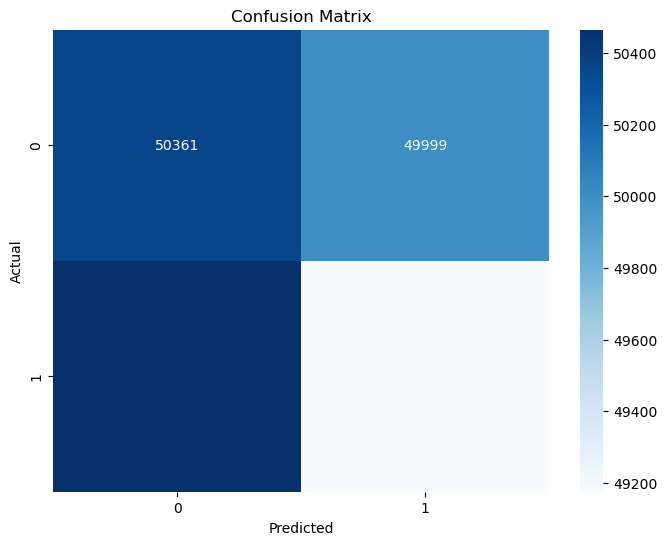

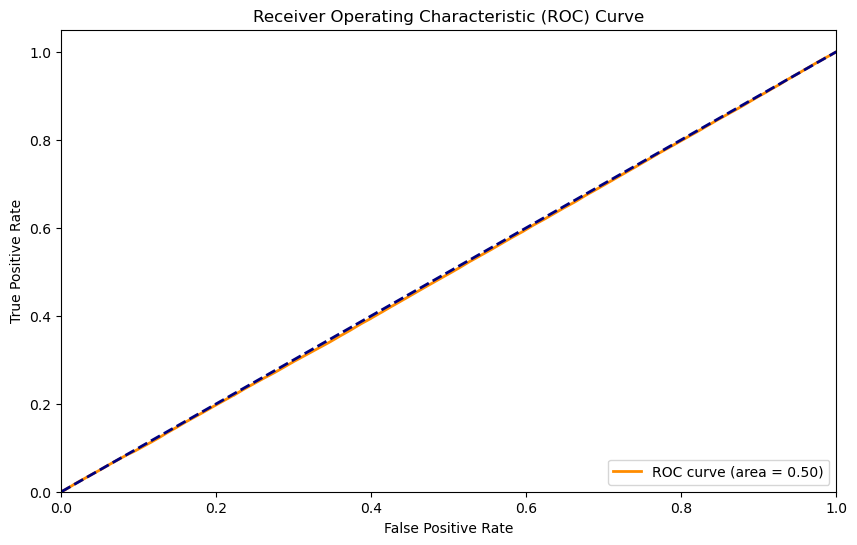

Logistic Regression Model Evaluation:
Accuracy: 0.499175, F1 Score: 0.4766855620281602


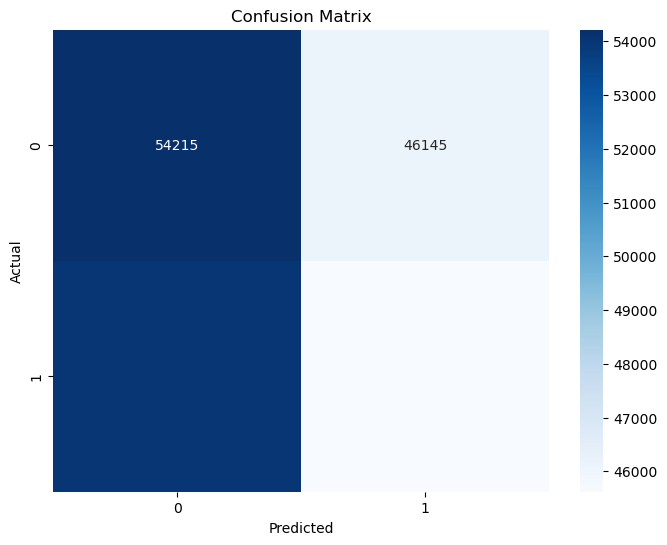

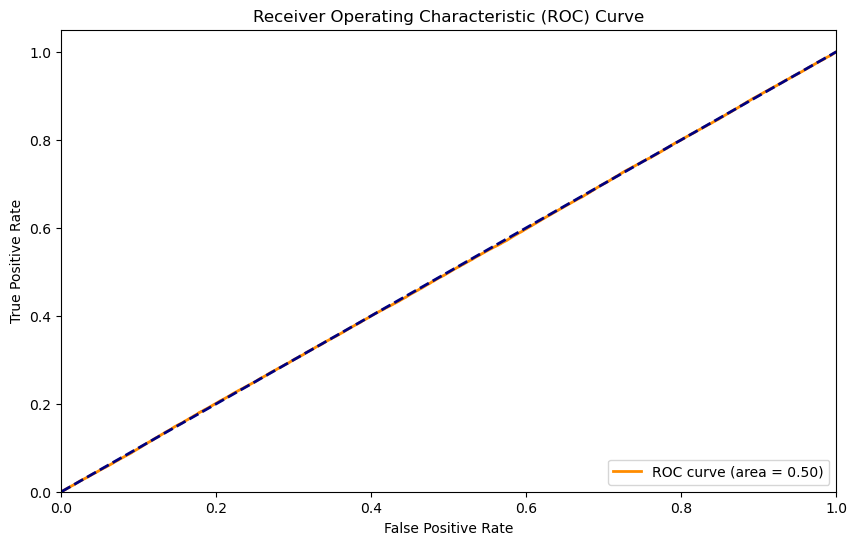

In [5]:
def evaluate_model(pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    print(f"Accuracy: {accuracy}, F1 Score: {f1}")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()

print("Random Forest Model Evaluation:")
evaluate_model(pipeline_rf, X_test, y_test)

print("Logistic Regression Model Evaluation:")
evaluate_model(pipeline_lr, X_test, y_test)


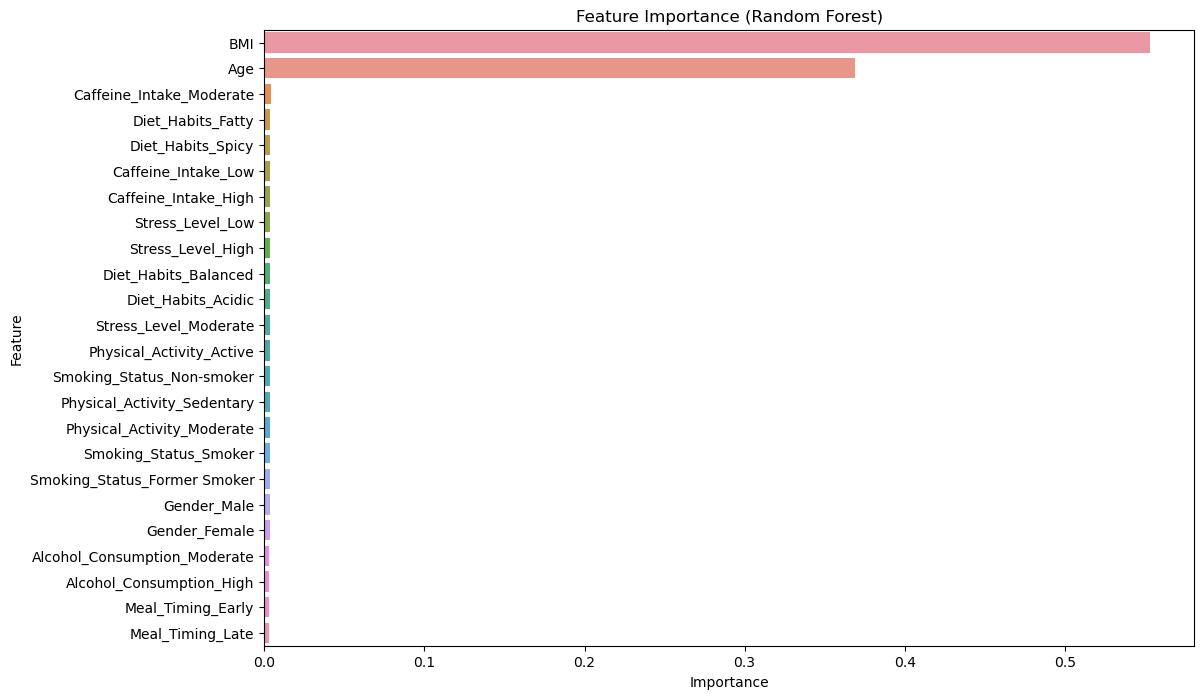

In [6]:
def plot_feature_importance(pipeline):
    feature_importances = pipeline.named_steps['classifier'].feature_importances_
    feature_names = pipeline.named_steps['preprocessor'].transformers_[1][1].named_steps['onehot'].get_feature_names_out(categorical_columns)
    numeric_feature_names = numeric_columns
    all_feature_names = np.concatenate([numeric_feature_names, feature_names])
    
    importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': feature_importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Feature Importance (Random Forest)')
    plt.show()

plot_feature_importance(pipeline_rf)


In [7]:
# Define new data
new_data = pd.DataFrame({
    'Age': [30, 45],
    'Gender': ['Male', 'Female'],
    'Diet_Habits': ['Balanced', 'Acidic'],
    'Alcohol_Consumption': ['Moderate', 'High'],
    'Smoking_Status': ['Non-smoker', 'Former Smoker'],
    'Caffeine_Intake': ['Low', 'High'],
    'Meal_Timing': ['Early', 'Late'],
    'BMI': [22.0, 30.0],
    'Physical_Activity': ['Moderate', 'Active'],
    'Stress_Level': ['Low', 'Moderate']
})

# Ensure the new data columns match the training data
new_data_transformed = pipeline_rf.named_steps['preprocessor'].transform(new_data)

# Predict using the preprocessed new data
predictions_rf = pipeline_rf.named_steps['classifier'].predict(new_data_transformed)
predictions_lr = pipeline_lr.named_steps['classifier'].predict(new_data_transformed)

print("Random Forest Predictions for new data:", predictions_rf)
print("Logistic Regression Predictions for new data:", predictions_lr)


Random Forest Predictions for new data: [1 1]
Logistic Regression Predictions for new data: [1 0]


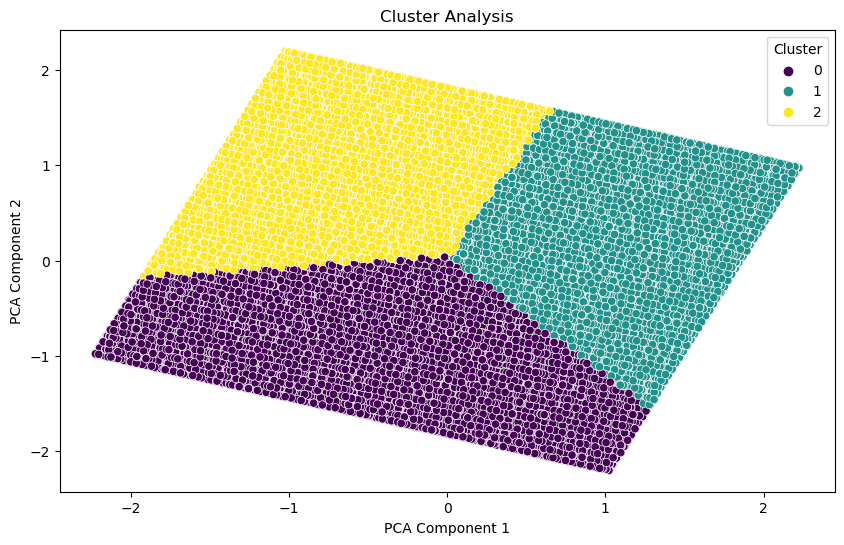

In [8]:
# Apply PCA for dimensionality reduction before clustering
pca = PCA(n_components=2)
X_pca = pca.fit_transform(pipeline_rf.named_steps['preprocessor'].transform(X))

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)
df['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis')
plt.title('Cluster Analysis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


Acidity_Status
0    500518
1    499482
Name: count, dtype: int64


C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


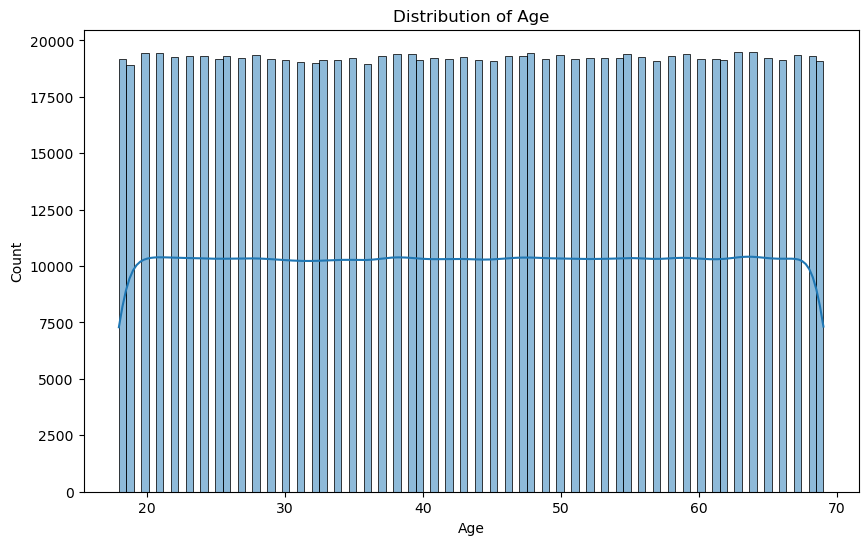

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


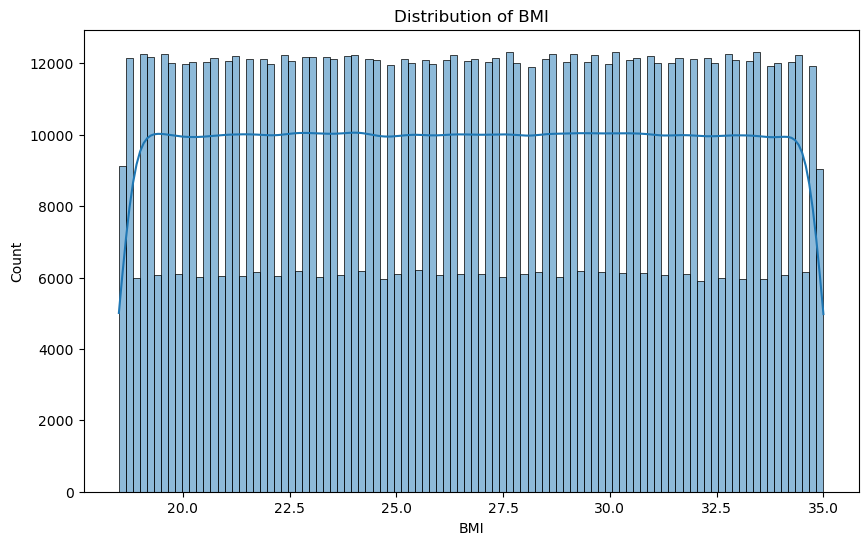

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


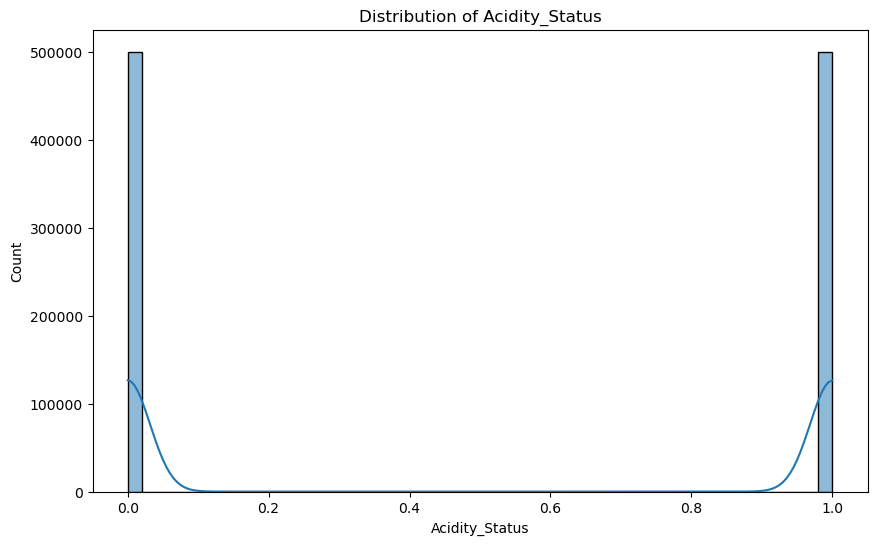

C:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


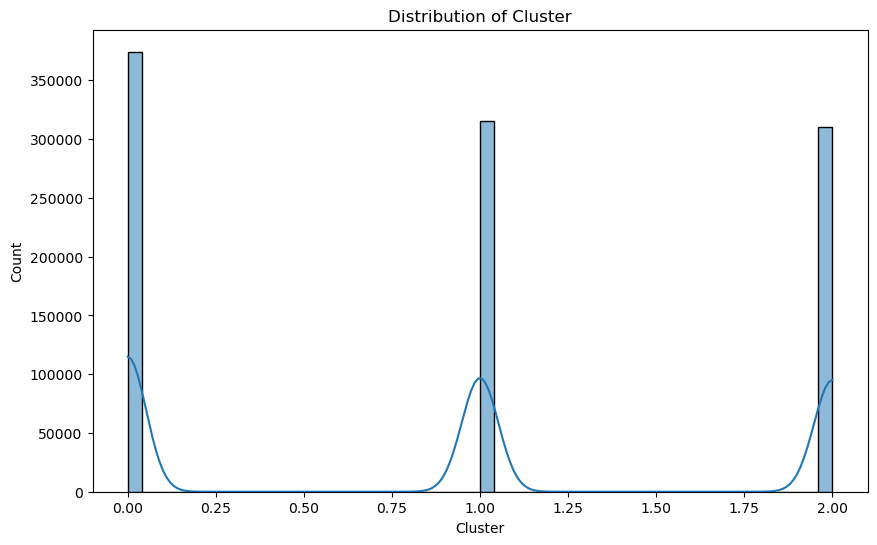

In [9]:
# Check class distribution
print(df['Acidity_Status'].value_counts())

# Visualize feature distributions
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns:
    if df[col].dtype != 'object':
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()


In [10]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20]
}

# Define GridSearchCV
grid_search = GridSearchCV(pipeline_rf, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
5 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator.fit(Xt, y

Best parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Best score: 0.5008637499999999


In [11]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean()}')


Cross-Validation Accuracy Scores: [0.498475   0.500575   0.4992875  0.50164375 0.50003125]
Mean Cross-Validation Accuracy: 0.5000025


In [25]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean()}')


Cross-Validation Accuracy Scores: [0.498475   0.500575   0.4992875  0.50164375 0.50003125]
Mean Cross-Validation Accuracy: 0.5000025
